In [4]:
# 1. Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load Data
data = pd.read_csv('retail_sales_dataset.csv')
data.head()

# 4. Check Dataset General Information
print(data.info())

# 5. Check Descriptive Statistics
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    

In [7]:
#Missing Value
missing_values = data.isnull().sum()
missing_values[missing_values > 0]

,0


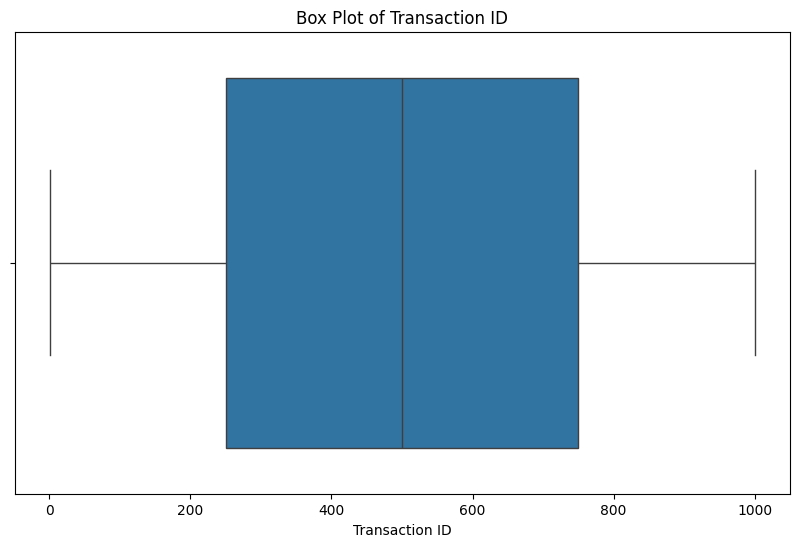

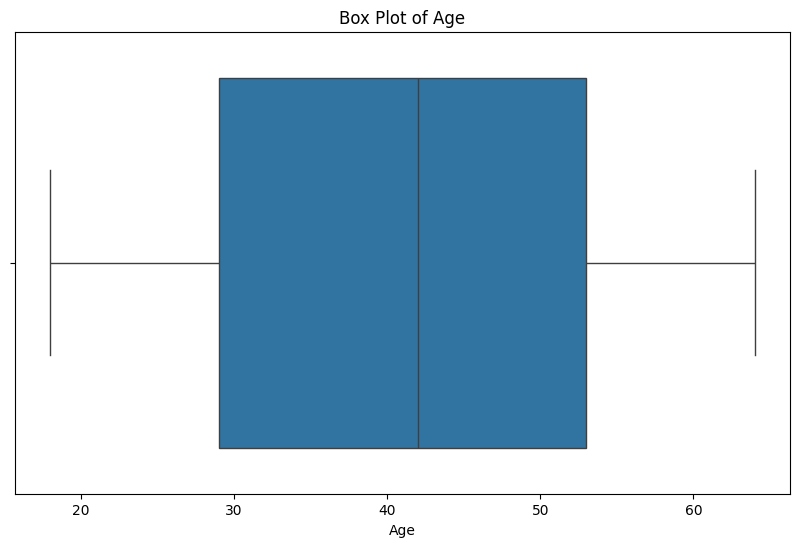

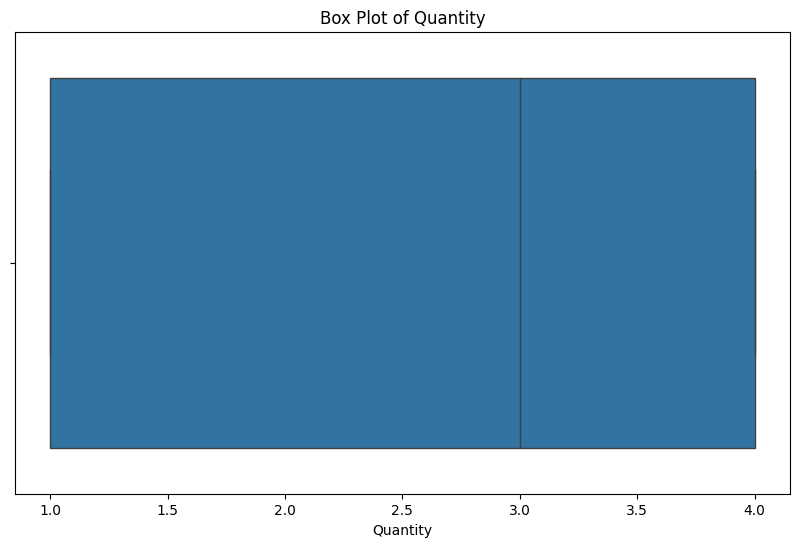

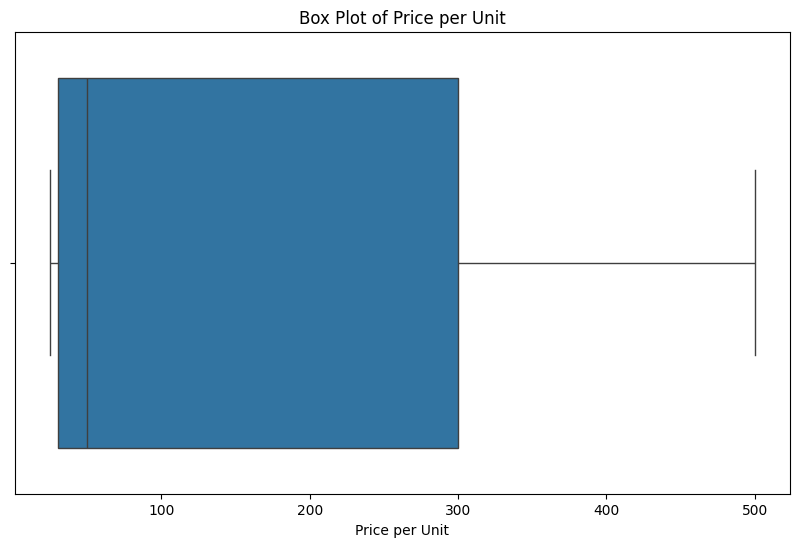

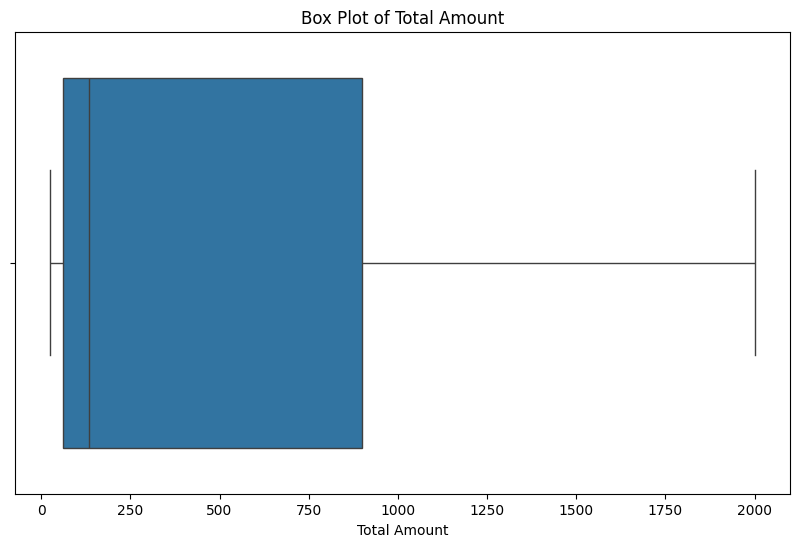

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = data.select_dtypes(include=['int64', 'float64']).columns

for feature in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=data[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

Best Selling Products:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


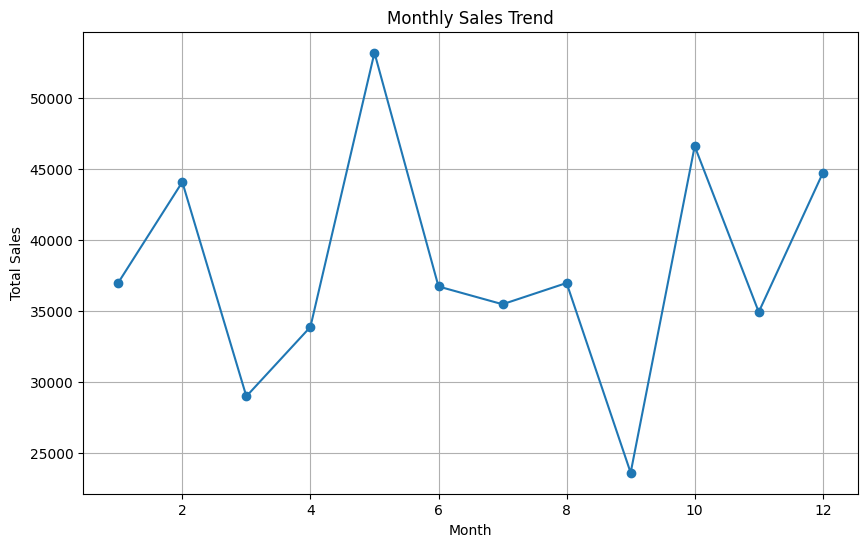

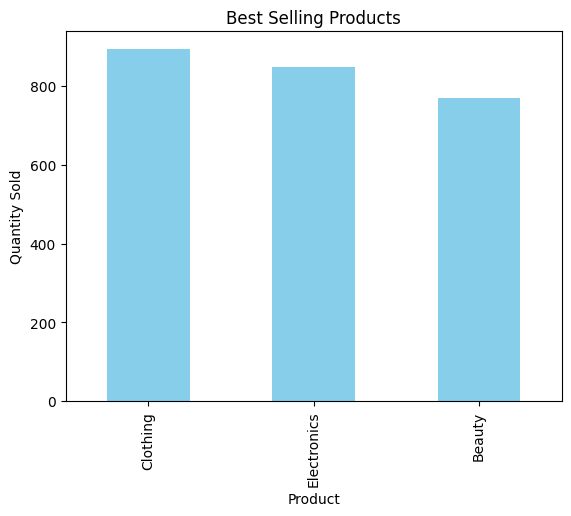

In [8]:
data['Total Sales'] = data['Price per Unit'] * data['Quantity']

# 7. Display Best Selling Products
top_products = data.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
print("Best Selling Products:")
print(top_products)


# 8. Sales Time Analysis (Best Month)
# Convert Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])
data['Month'] = data['Date'].dt.month
monthly_sales = data.groupby('Month')['Total Sales'].sum()

# 9. Monthly Sales Visualization
plt.figure(figsize=(10,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid()
plt.show()

# 10. Best Selling Product Visualization
top_products.plot(kind='bar', color='skyblue')
plt.title('Best Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.show()